In [1]:
from deeplatent import Corpus, GTM, generate_documents
from sklearn.feature_extraction.text import CountVectorizer

df_theta, df, topic_words, true_lambda, true_label_coeffs = generate_documents(
    num_docs=10000,
    num_topics=3,
    vocab_size=500,
    min_words=100,
    max_words=100,
    num_covs=2,
    num_languages=1,
    doc_topic_prior="logistic_normal",
    label_type="regression",
    random_seed=1234
)

In [2]:
# ---- 1. Fit vectorizer on training set ----
vectorizer = CountVectorizer()  
vectorizer.fit(df["doc_clean_0"])

# ---- 2. Define modalities using this vectorizer ----
modalities = {
    "text": {
        "column": "doc_clean_0",
        "views": {
            "bow": {
                "type": "bow",
                "vectorizer": vectorizer
            }
        }
    }
}

# ---- 3. Create GTMCorpus datasets ----
train_dataset = Corpus(
    df,
    modalities=modalities,
    labels="~label-1",
    prevalence="~cov_1 + cov_2"
)

In [6]:
# Train the model

encoder_args = {
    "text_bow": {
        "hidden_dims": [128,64],
        "activation": "relu",
        "bias": True,
        "dropout": 0.0
    }
}

decoder_args = {
    "text_bow": {
        "hidden_dims": [64,128],
        "activation": "relu",
        "bias": True,
        "dropout": 0.0
    }
}

predictor_args = {
    "text_bow": {
        "hidden_dims": [],
        "activation": "relu",
        "bias": False,
        "dropout": 0.0
    }
}

optim_args = {
    "main": {
        "lr": 1e-3, 
        "weight_decay": 0.0  # L2 penalty for main parameters 
    }
}

tm = GTM(
    train_dataset, 
    ae_type="vae",
    update_prior=True,
    optim_args=optim_args,
    encoder_args=encoder_args,
    decoder_args=decoder_args,
    predictor_args=predictor_args,
    n_topics=3,
    batch_size=100,
    predictor_type='regressor', 
    w_pred_loss=1,
    w_prior=1,
    print_every_n_steps=1,
    num_steps=10000,
    encoder_steps_per_decoder=20
)

Step      1	Mean Training Loss:7.0174155
Rec Loss:6.1339598
Divergence Loss:0.5515867
Pred Loss:0.3318692

Step      2	Mean Training Loss:6.7717857
Rec Loss:6.1182580
Divergence Loss:0.3663404
Pred Loss:0.2871878

Step      3	Mean Training Loss:6.5284572
Rec Loss:6.1074266
Divergence Loss:0.1031087
Pred Loss:0.3179216

Step      4	Mean Training Loss:6.5443611
Rec Loss:6.0913210
Divergence Loss:0.1446889
Pred Loss:0.3083513

Step      5	Mean Training Loss:6.4603572
Rec Loss:6.0772166
Divergence Loss:0.0811135
Pred Loss:0.3020271

Step      6	Mean Training Loss:6.4234819
Rec Loss:6.0590425
Divergence Loss:0.0572308
Pred Loss:0.3072084

Step      7	Mean Training Loss:6.4730010
Rec Loss:6.0377212
Divergence Loss:0.1293567
Pred Loss:0.3059228

Step      8	Mean Training Loss:6.3607588
Rec Loss:6.0198517
Divergence Loss:0.0431405
Pred Loss:0.2977666

Step      9	Mean Training Loss:6.3808994
Rec Loss:5.9988084
Divergence Loss:0.0413062
Pred Loss:0.3407849

Step     10	Mean Training Loss:6.2736

KeyboardInterrupt: 

Topic alignment permutation: [0 1 2]
Correlation matrix:
 [[-0.01439787  0.00087706  0.01431867]
 [-0.00458426 -0.00347648  0.00906144]
 [ 0.01536684  0.00241874 -0.01930409]]


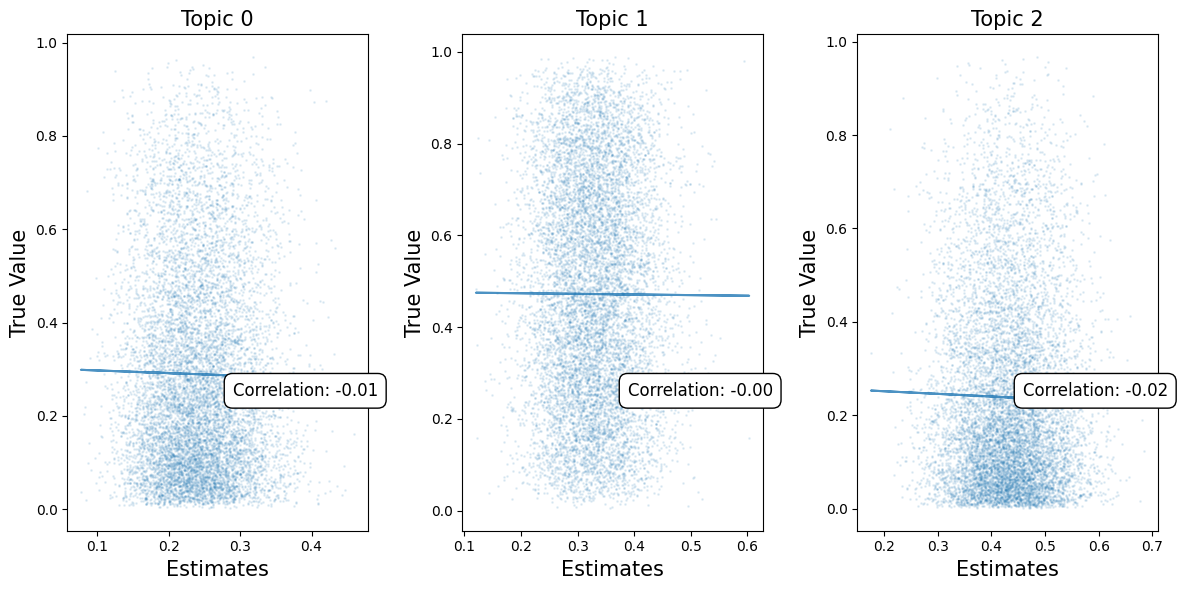

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

# Step 1 — get estimated doc-topic matrix
full_dataset = Corpus(
    df,
    modalities=modalities,
    labels="~label-1",
    prevalence="~cov_1 + cov_2"
)
estimated_doc_topics = tm.get_doc_topic_distribution(full_dataset, num_samples=30)

# Step 2 — align topics using Hungarian algorithm
K = estimated_doc_topics.shape[1]
corr_matrix = np.zeros((K, K))

for i in range(K):
    for j in range(K):
        corr_matrix[i, j] = np.corrcoef(
            estimated_doc_topics[:, i],
            df_theta[f"Topic{j}"]
        )[0, 1]

# maximize absolute correlation
row_ind, col_ind = linear_sum_assignment(-np.abs(corr_matrix))

# reorder df_theta based on optimal assignment
df_theta_aligned = df_theta[[f"Topic{j}" for j in col_ind]]
df_theta_aligned.columns = [f"Topic{i}" for i in range(K)]

print("Topic alignment permutation:", col_ind)
print("Correlation matrix:\n", corr_matrix)

# Step 3 — plotting (same as your code)
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

for i in range(3):
    x = estimated_doc_topics[:, i]
    y = df_theta_aligned[f"Topic{i}"]
    
    axs[i].scatter(x, y, s=1, alpha=0.1)
    
    coefficients = np.polyfit(x, y, 1)
    fit = np.poly1d(coefficients)
    axs[i].plot(x, fit(x), alpha=0.8)
    
    axs[i].set_xlabel('Estimates', fontsize=15)
    axs[i].set_ylabel('True Value', fontsize=15)
    axs[i].set_title(f'Topic {i}', fontsize=15)

    corr_coeff = np.corrcoef(x, y)[0, 1]
    axs[i].annotate(
        f'Correlation: {corr_coeff:.2f}',
        xy=(0.55, 0.3), xycoords='axes fraction',
        fontsize=12, verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
    )

plt.tight_layout()
plt.show()


In [5]:
print("True label_coeffs:\n", true_label_coeffs)

print('Estimated weights:')
print(tm.predictor.neural_net["pred_0"].weight.detach().cpu())

True label_coeffs:
 [-0.814588    0.41718749  0.45773178]
Estimated weights:
tensor([[0.1673, 0.2474, 0.1398]])


In [6]:
tm.get_predictions(full_dataset, to_numpy=False, num_samples=30)[0:10]

tensor([[0.0589],
        [0.0715],
        [0.0822],
        [0.0585],
        [0.0854],
        [0.0725],
        [0.0756],
        [0.0594],
        [0.0659],
        [0.0630]], device='cuda:0')

In [7]:
print(df['label'].iloc[0:10])

0    0.299451
1    0.344011
2    0.289740
3   -0.392198
4    0.310445
5    0.195428
6    0.127682
7   -0.301513
8    0.335144
9    0.352473
Name: label, dtype: float64
